# Multiple-merger coalescents
Supported coalescent models are {class}`~phasegen.coalescent_models.StandardCoalescent`, {class}`~phasegen.coalescent_models.BetaCoalescent` and {class}`~phasegen.coalescent_models.DiracCoalescent`, and can be specified when constructing the {class}`~phasegen.distributions.Coalescent` distribution.

In [1]:
Sys.setenv(TQDM_DISABLE = "1")
setwd("~/PycharmProjects/PhaseGen/")
reticulate::use_condaenv("/Users/janek/miniforge3/envs/dev-phasegen", required = TRUE)

In [2]:
mpl <- reticulate::import("matplotlib")
mpl$use("Agg")
plt <- reticulate::import("matplotlib.pyplot")
plt$rcParams[["figure.figsize"]] <- c(4.4, 3.3)
options(repr.plot.width = 4.4, repr.plot.height = 3.3)

# render a phasegen plot object (calls its .plot()) inline
render <- function(obj) {
  p <- tempfile(fileext = ".png"); obj$plot(show = FALSE, file = p); IRdisplay::display_png(file = p)
}
# render an arbitrary matplotlib figure drawn by `draw`, which saves to the given path
render_fn <- function(draw) {
  p <- tempfile(fileext = ".png"); draw(p); IRdisplay::display_png(file = p)
}
# run a call and echo the phasegen log output it emits, so it is captured in the rendered cell
with_log <- function(expr) cat(reticulate::py_capture_output(expr))

In [3]:
library(phasegen)

pg <- load_phasegen()

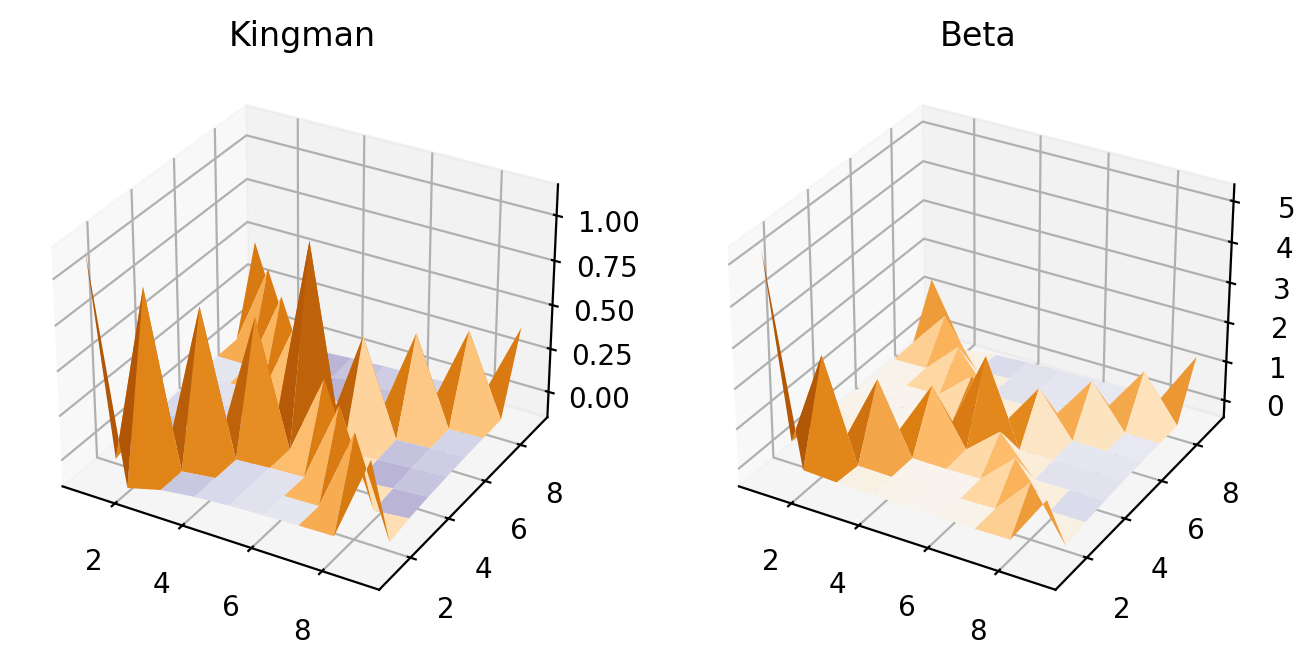

In [4]:
# compare 2-SFS of Kingman and Beta coalescents
kingman <- pg$Coalescent(n = 10L, model = pg$StandardCoalescent())
beta <- pg$Coalescent(n = 10L, model = pg$BetaCoalescent(alpha = 1.5))

# beta coalescent shows positive correlations between disparate minor allele frequencies
render_fn(function(f) {
    res <- plt$subplots(ncols = 2L, figsize = c(8, 4), subplot_kw = list(projection = "3d"))
    axs <- res[[2]]
    kingman$sfs$cov$plot_surface(ax = axs[[1]], show = FALSE, title = "Kingman")
    beta$sfs$cov$plot_surface(ax = axs[[2]], show = FALSE, title = "Beta")
    plt$savefig(f, dpi = 200, bbox_inches = "tight"); plt$close("all")
})